# Session 8 — End-to-end demo

This notebook runs the full parent graph (PII → TODO → Sysbox bash → demask).

**No prosa yet ;-)**. 

**There is no separate "agent" service.** Agent behavior is Python/LangGraph code inside the `dev` container — typically driven from this notebook.

The cells below archive two C4 infrastructure views (raw draft; detail work later), then the live graph demo.

## C4 Level 1 — System Context

One software system (`LLM Agent Lab`), one person, optional externals. No LiteLLM/Ollama detail here — that is Level 2.

| Element | Role |
|---------|------|
| Developer | Edits notebooks, calls `graph.ainvoke` |
| LLM Agent Lab | Docker Compose stack |
| Cloud LLM Providers | Optional (API keys) |
| Host Browser | Jupyter `:8888`, Phoenix UI `:6006` |

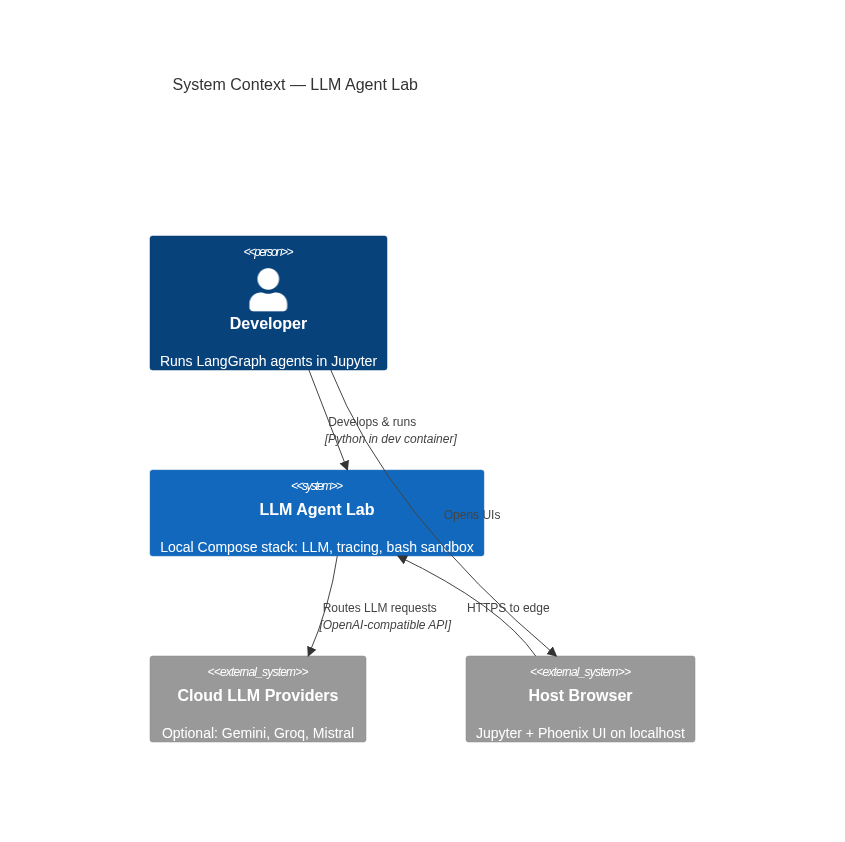

In [3]:
from IPython.display import Image, display
from langchain_core.runnables.graph_mermaid import draw_mermaid_png

SYSTEM_CONTEXT_MERMAID = """
C4Context
    title System Context — LLM Agent Lab

    Person(dev, "Developer", "Runs LangGraph agents in Jupyter")
    System(lab, "LLM Agent Lab", "Local Compose stack: LLM, tracing, bash sandbox")
    System_Ext(cloud, "Cloud LLM Providers", "Optional: Gemini, Groq, Mistral")
    System_Ext(browser, "Host Browser", "Jupyter + Phoenix UI on localhost")

    Rel(dev, lab, "Develops & runs", "Python in dev container")
    Rel(dev, browser, "Opens UIs")
    Rel(browser, lab, "HTTPS to edge")
    Rel(lab, cloud, "Routes LLM requests", "OpenAI-compatible API")
"""

SYSTEM_CONTEXT_FALLBACK = """
flowchart TB
  dev[Developer]
  lab[LLM Agent Lab]
  cloud[Cloud LLM Providers]
  browser[Host Browser]
  dev -->|develops and runs| lab
  dev --> browser
  browser -->|HTTPS| lab
  lab -.->|optional| cloud
"""


def display_mermaid(diagram: str, *, fallback: str | None = None) -> None:
    try:
        display(Image(draw_mermaid_png(diagram)))
    except Exception as exc:
        if fallback is None:
            raise
        print(f"C4 render failed ({exc}); showing flowchart fallback.")
        display(Image(draw_mermaid_png(fallback)))


display_mermaid(SYSTEM_CONTEXT_MERMAID, fallback=SYSTEM_CONTEXT_FALLBACK)

## C4 Level 2 — Container

Deployable units inside the lab. **Agent code lives in `dev`**, not in its own service box.

### Agent-relevant endpoints (from `dev`)

| Traffic | URL | Used for |
|---------|-----|----------|
| LLM clean | `https://caddy:4000/v1/...` | `MODEL_BASE_URL_CLEAN` |
| LLM chaos | `https://caddy:4001/v1/...` | `MODEL_BASE_URL_CHAOS` |
| App traces | `https://caddy:6006/v1/traces` | LangGraph tree (`langgraph-course`) |
| Bash sandbox | `http://sysbox_bash:8080` | `SBASH_BASE_URL` — direct, not via Caddy |
| Optional RAG | `postgres:5432` | pgvector |

**Network rule:** LLM and trace traffic go through **Caddy** (`dev_edge`). **Exception:** `sysbox_bash` is reached directly on `backend_core`.

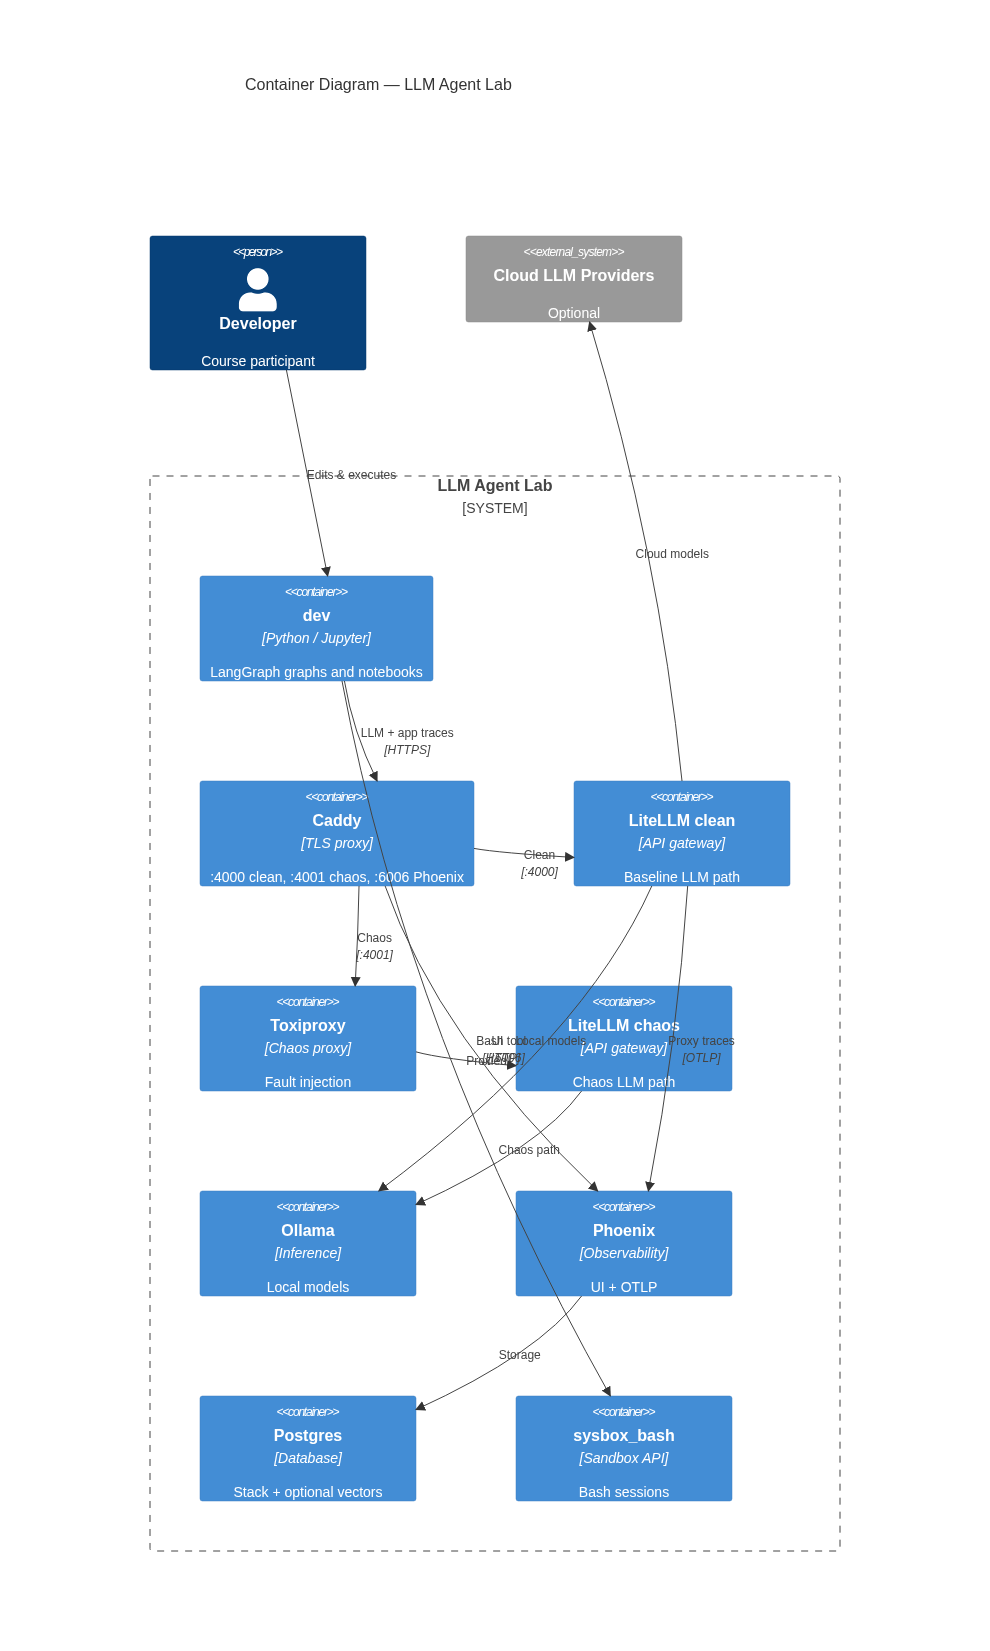

In [4]:
CONTAINER_MERMAID = """
C4Container
    title Container Diagram — LLM Agent Lab

    Person(dev_person, "Developer", "Course participant")

    System_Boundary(lab, "LLM Agent Lab") {
        Container(dev, "dev", "Python / Jupyter", "LangGraph graphs and notebooks")
        Container(caddy, "Caddy", "TLS proxy", ":4000 clean, :4001 chaos, :6006 Phoenix")
        Container(llm_clean, "LiteLLM clean", "API gateway", "Baseline LLM path")
        Container(toxi, "Toxiproxy", "Chaos proxy", "Fault injection")
        Container(llm_chaos, "LiteLLM chaos", "API gateway", "Chaos LLM path")
        Container(ollama, "Ollama", "Inference", "Local models")
        Container(phoenix, "Phoenix", "Observability", "UI + OTLP")
        Container(pg, "Postgres", "Database", "Stack + optional vectors")
        Container(sbash, "sysbox_bash", "Sandbox API", "Bash sessions")
    }

    System_Ext(cloud, "Cloud LLM Providers", "Optional")

    Rel(dev_person, dev, "Edits & executes")
    Rel(dev, caddy, "LLM + app traces", "HTTPS")
    Rel(dev, sbash, "Bash tool", "HTTP")
    Rel(caddy, llm_clean, "Clean", ":4000")
    Rel(caddy, toxi, "Chaos", ":4001")
    Rel(caddy, phoenix, "UI", ":6006")
    Rel(toxi, llm_chaos, "Proxied")
    Rel(llm_clean, ollama, "Local models")
    Rel(llm_clean, cloud, "Cloud models")
    Rel(llm_chaos, ollama, "Chaos path")
    Rel(llm_clean, phoenix, "Proxy traces", "OTLP")
    Rel(phoenix, pg, "Storage")
"""

CONTAINER_FALLBACK = """
flowchart TB
  subgraph lab [LLM Agent Lab]
    dev[dev]
    caddy[Caddy]
    llm_clean[LiteLLM clean]
    toxi[Toxiproxy]
    llm_chaos[LiteLLM chaos]
    ollama[Ollama]
    phoenix[Phoenix]
    pg[Postgres]
    sbash[sysbox_bash]
  end
  cloud[Cloud LLM Providers]
  dev -->|HTTPS| caddy
  dev -->|HTTP| sbash
  caddy --> llm_clean
  caddy --> toxi
  caddy --> phoenix
  toxi --> llm_chaos
  llm_clean --> ollama
  llm_clean -.-> cloud
  llm_chaos --> ollama
  llm_clean --> phoenix
  phoenix --> pg
"""

display_mermaid(CONTAINER_MERMAID, fallback=CONTAINER_FALLBACK)

## Application layer — LangGraph pipeline

Infrastructure above; below: the graph compiled in this notebook (component-level view inside `dev`).

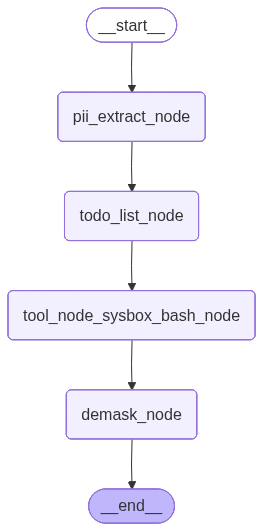

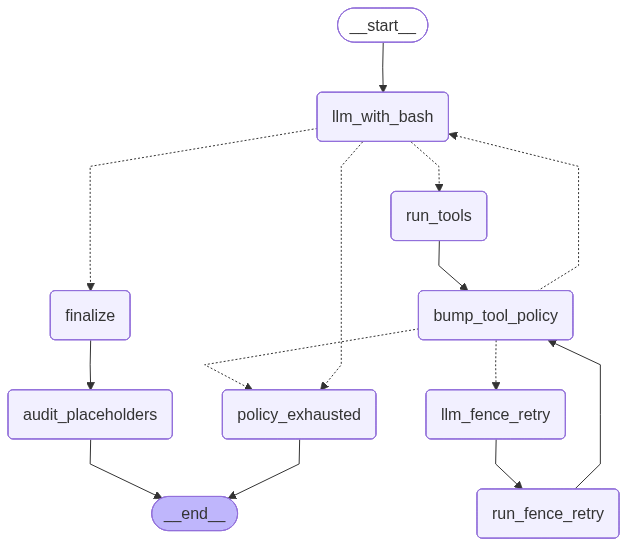

In [5]:
import os
import sys

sys.path.insert(0, "/workspace")

from src.tracing.phoenix import enable_langgraph_tracing

enable_langgraph_tracing(batch=True, verbose=False)

if not os.getenv("PHOENIX_COLLECTOR_ENDPOINT"):
    raise RuntimeError("Missing PHOENIX_COLLECTOR_ENDPOINT")
if not os.getenv("SBASH_BASE_URL"):
    raise RuntimeError("Missing SBASH_BASE_URL — is sysbox_bash healthy?")

from langchain_core.messages import HumanMessage
from langgraph.graph import END, START, StateGraph
from IPython.display import Image, display
import logging

from src.llm_nodes.global_state import GlobalState
from src.llm_nodes.pii_email.nodes import get_pii_email_node
from src.llm_nodes.todo_extract.graph import (
    build_todo_extract_subgraph,
    make_todo_extract_subgraph_runner,
)
from src.llm_nodes.tool_node_sysbox_bash.graph import (
    build_tool_node_sysbox_bash_subgraph,
    make_tool_node_sysbox_bash_subgraph_runner,
)
from src.other_nodes.demask.nodes import get_demask_node
from src.logging_setup import get_logger
from src.reducer.base_reader import BaseReducerReader
from src.reducer.reducer_session import reducer_session

# MODEL = "ollama_chat/llama3.2:3b"
# MODEL = "groq/llama-3.3-70b-versatile"
# MODEL="ollama_chat/mistral:7b"
MODEL="mistral-large-old"

pii_email = """
This is a confidential email.

Task ulf.wendel@ phpdoc dot de to buy a cup of coffee, ulf.wendel@phpdoc.de needs to plant a tree by tomorrow,
and cto@ourcompany.com needs to reach out to all employees
regarding the current coffee shortage as it is demotivating our technical staff.
Due date, if not said otherwise, is today.
"""

GRAPH_RECURSION_LIMIT = 50

logger = get_logger(__name__, "assorted/session8/presentation.ipynb")
logger.setLevel(logging.DEBUG)

todo_extract_graph = build_todo_extract_subgraph(MODEL)
run_todo_extract_graph = make_todo_extract_subgraph_runner(todo_extract_graph)

tool_node_sysbox_bash_graph = build_tool_node_sysbox_bash_subgraph(MODEL)
run_tool_node_sysbox_bash_graph = make_tool_node_sysbox_bash_subgraph_runner(
    tool_node_sysbox_bash_graph
)


build_graph = StateGraph(GlobalState)

build_graph.add_node("pii_extract_node", get_pii_email_node(model=MODEL))
build_graph.add_node("todo_list_node", run_todo_extract_graph)
build_graph.add_node("tool_node_sysbox_bash_node", run_tool_node_sysbox_bash_graph)
build_graph.add_node("demask_node", get_demask_node())

build_graph.add_edge(START, "pii_extract_node")
build_graph.add_edge("pii_extract_node", "todo_list_node")
build_graph.add_edge("todo_list_node", "tool_node_sysbox_bash_node")
build_graph.add_edge("tool_node_sysbox_bash_node", "demask_node")
build_graph.add_edge("demask_node", END)

graph = build_graph.compile()

display(Image(graph.get_graph().draw_mermaid_png()))
display(Image(tool_node_sysbox_bash_graph.get_graph().draw_mermaid_png()))

In [6]:
def make_reader(get_thread_id):
    return BaseReducerReader(get_thread_id=get_thread_id)


with reducer_session("Chat-sysbox-bash", factory=make_reader) as session:
    state = session.state(GlobalState, [HumanMessage(content=pii_email)])
    reply = await session.ainvoke(
        graph,
        state,
        config={"recursion_limit": GRAPH_RECURSION_LIMIT},
    )
    state = GlobalState.model_validate(reply)

    print("TODO list:")
    for k, item in enumerate(state.todo_list.items):
        print(f"  {k + 1}): who={item.who}, what={item.what}, when={item.when}")

    print("\nDeliverable (demasked by demask_node in graph):")
    print(state.final_result)

[DEBUG] [reducer/base_reader.py:51] observing message content: 
This is a confidential email.

Task ulf.wendel@ phpdoc dot de to buy a cup of coffee, ulf.wendel@phpdoc.de needs to plant a tree by tomorrow,
and cto@ourcompany.com needs to reach out to all employees
regarding the current coffee shortage as it is demotivating our technical staff.
Due date, if not said otherwise, is today.

[DEBUG] [reducer/base_reader.py:51] observing message content: ```json
{"occurrences": [{"span": "ulf.wendel@ phpdoc dot de", "raw": "ulf.wendel@phpdoc.de"}, {"span": "ulf.wendel@phpdoc.de", "raw": "ulf.wendel@phpdoc.de"}, {"span": "cto@ourcompany.com", "raw": "cto@ourcompany.com"}]}
```
[DEBUG] [reducer/base_reader.py:51] observing message content: {"items": [{"who": "E0_479bf1e0", "what": "buy a cup of coffee", "when": "today"}, {"who": "E0_479bf1e0", "what": "plant a tree", "when": "tomorrow"}, {"who": "E1_479bf1e0", "what": "reach out to all employees regarding the current coffee shortage", "when": 

TODO list:
  1): who=E0_479bf1e0, what=buy a cup of coffee, when=today
  2): who=E0_479bf1e0, what=plant a tree, when=tomorrow
  3): who=E1_479bf1e0, what=reach out to all employees regarding the current coffee shortage, when=today

Deliverable (demasked by demask_node in graph):
# ulf.wendel@phpdoc.de
- [ ] coffee of cup a buy (5 words) (by today)
  ```
   ( (
    ) )
 ........
 |      |]

  sandbox probe — Kernel version running in the sandbox: 7.0.12-1-default
  ```

- [ ] tree a plant (3 words) (by tomorrow)
  ```
     *
    ***
   *****
  *******
     |

  sandbox probe — Number of CPU cores available in the sandbox: 10
  ```

# cto@ourcompany.com
- [ ] shortage coffee current the regarding employees all to out reach (10 words) (by today)
  ```
  ( (
   ) )
  .......
  |    |
  |____|
   |  |
   |__|

  sandbox probe — Current working directory path in the sandbox: /sandbox/session
  ```
